In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("../data/raw/healthcare_raw.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
df.shape

(1338, 7)

In [13]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [14]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [15]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [16]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(1)

In [18]:
df = df.drop_duplicates()

In [20]:
# Fix warning permanently
df = df.copy()

# Encoding
df['sex'] = df['sex'].map({'male':1, 'female':0})
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})

In [21]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,NaN,27.900,0,NaN,16884.92400,False,False,True
1,18,NaN,33.770,1,NaN,1725.55230,False,True,False
2,28,NaN,33.000,3,NaN,4449.46200,False,True,False
3,33,NaN,22.705,0,NaN,21984.47061,True,False,False
4,32,NaN,28.880,0,NaN,3866.85520,True,False,False


In [22]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,NaN,27.900,0,NaN,16884.92400,False,False,True
1,18,NaN,33.770,1,NaN,1725.55230,False,True,False
2,28,NaN,33.000,3,NaN,4449.46200,False,True,False
3,33,NaN,22.705,0,NaN,21984.47061,True,False,False
4,32,NaN,28.880,0,NaN,3866.85520,True,False,False


In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               0 non-null      float64
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            0 non-null      float64
 5   charges           1337 non-null   float64
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(3), float64(4), int64(2)
memory usage: 77.0 KB


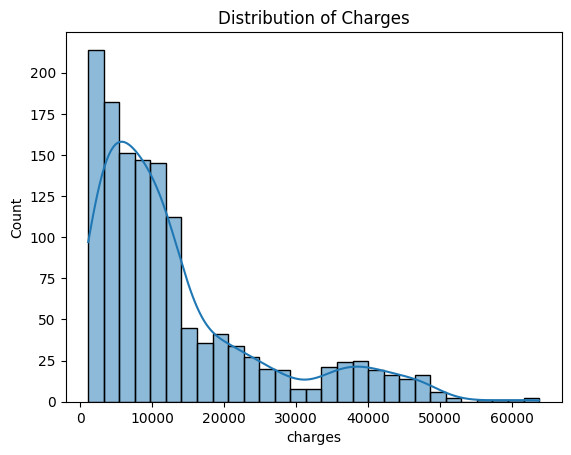

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Charges")
plt.show()

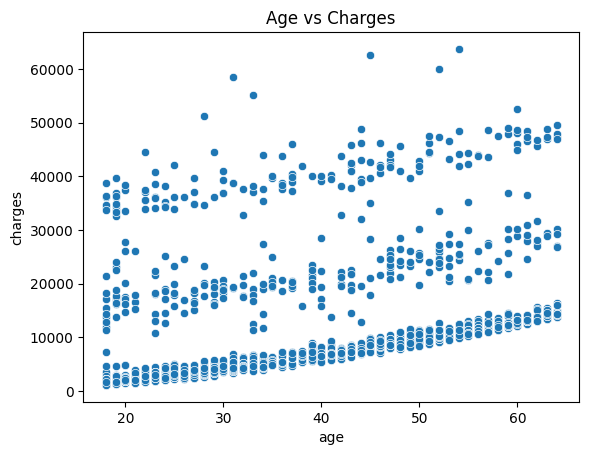

In [25]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

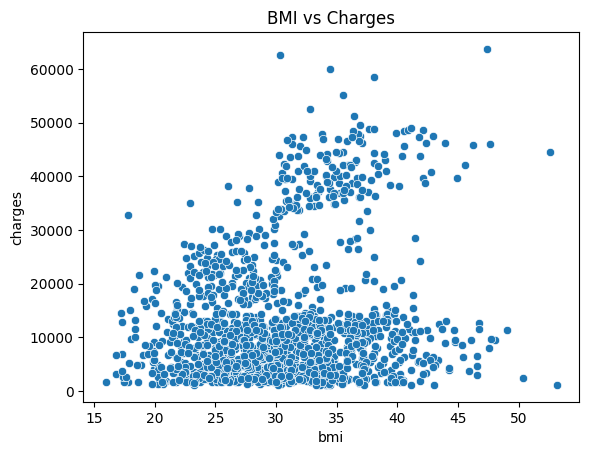

In [26]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

In [30]:
df.dtypes

age                   int64
sex                 float64
bmi                 float64
children              int64
smoker              float64
charges             float64
region_northwest       bool
region_southeast       bool
region_southwest       bool
smoker_label         object
dtype: object

In [32]:
df['smoker'].isnull().sum()

np.int64(1337)

In [33]:
df['smoker'] = df['smoker'].fillna(0)
df['smoker'] = df['smoker'].astype(int)

In [35]:
df = df[['smoker', 'charges']].copy()
df = df.dropna()
df = df.reset_index(drop=True)

In [36]:
df['smoker'] = df['smoker'].astype(int)
df['charges'] = pd.to_numeric(df['charges'], errors='coerce')

In [37]:
df['smoker_label'] = df['smoker'].map({0: 'No', 1: 'Yes'})

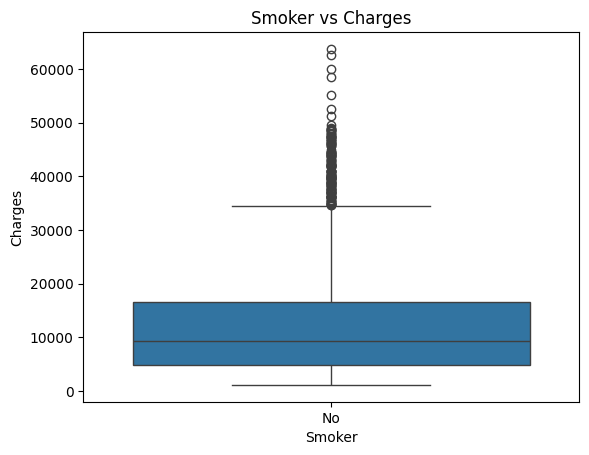

In [38]:
plt.figure()

sns.boxplot(
    x=df['smoker_label'].values,
    y=df['charges'].values
)

plt.title("Smoker vs Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

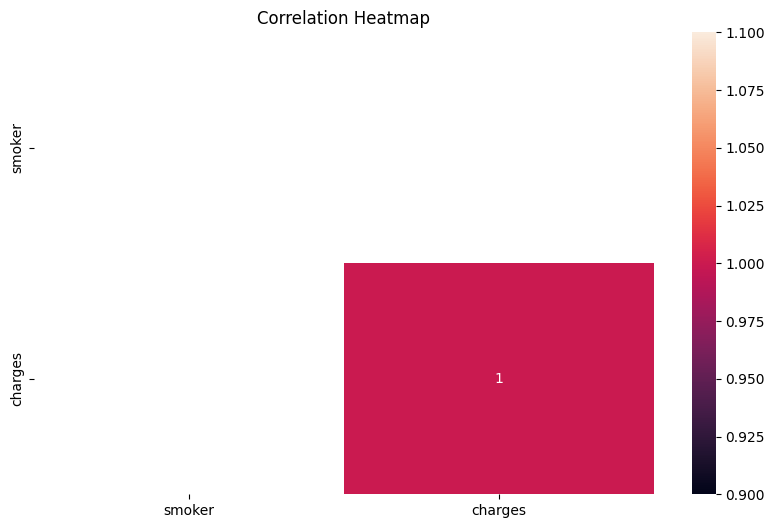

In [41]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [43]:
df = pd.read_csv("../data/raw/healthcare_raw.csv")

In [44]:
# remove missing values
df = df.dropna()

# encode
df['sex'] = df['sex'].map({'male':1, 'female':0})
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})

# one-hot encoding
df = pd.get_dummies(df, columns=['region'], drop_first=True)


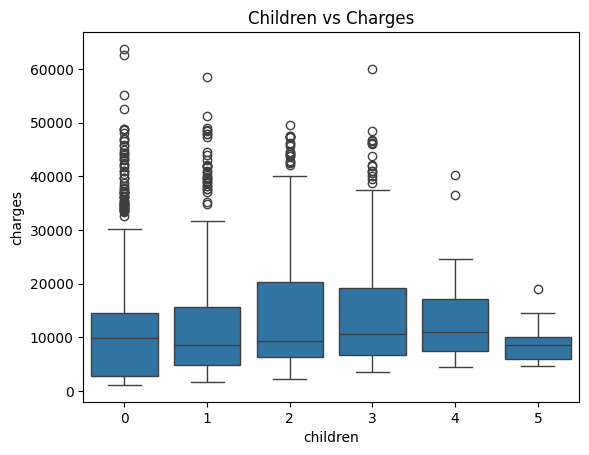

In [45]:
sns.boxplot(x='children', y='charges', data=df)
plt.title("Children vs Charges")
plt.show()

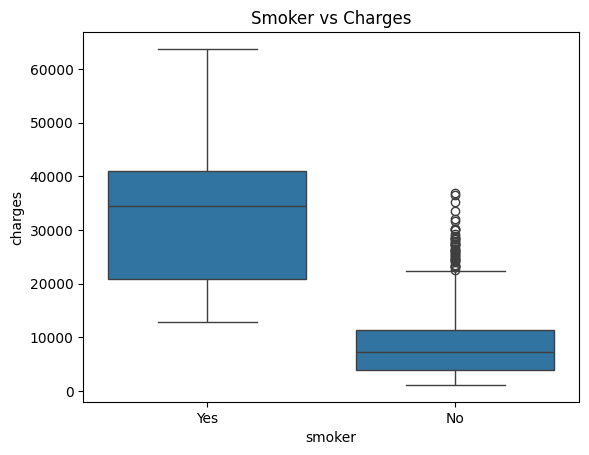

In [46]:
sns.boxplot(x=df['smoker'].map({0:'No',1:'Yes'}), y=df['charges'])
plt.title("Smoker vs Charges")
plt.show()

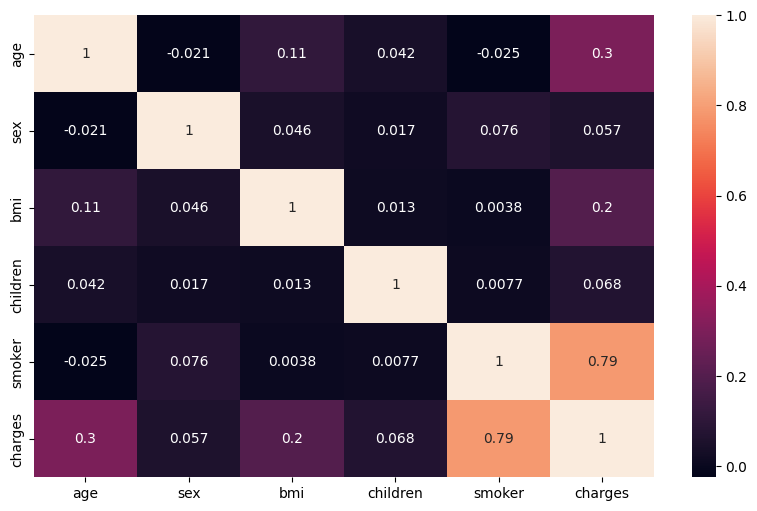

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

In [48]:
df.to_csv("../data/processed/healthcare_cleaned.csv", index=False)